# UNSW-NB15 — C3 Kernel Geometry Multi-Run (Statevector)

**Mục tiêu (1.4a):** Đánh giá độ ổn định của QSVM vs classical kernels (linear/poly/rbf) trên 5 cặp train/test parquet, regime statevector (noiseless), với C đã tune ở 1.3.

**Pipeline mỗi run (zero-leakage):** `parquet (186 features) → SelectKBest(K=35) → PCA(n=4) → MinMax[0,π] → SVC(kernel)`

**Kernels so sánh:** `quantum` (ZZFeatureMap reps=2 entanglement='full') · `linear` · `poly (degree=2)` · `rbf (gamma='scale')`

**Output:** F1 mean±std, McNemar QSVM vs RBF, KTA mean±std, 3 figures (boxplot/bar/confmat), JSON kết quả.

## 1. Config & Imports

In [1]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
warnings.filterwarnings('ignore')

from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              accuracy_score, confusion_matrix)
from scipy.stats import binomtest

from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityStatevectorKernel

import qiskit, qiskit_machine_learning, sklearn
print(f'Qiskit       : {qiskit.__version__}')
print(f'Qiskit-ML    : {qiskit_machine_learning.__version__}')
print(f'scikit-learn : {sklearn.__version__}')
print('Backend      : FidelityStatevectorKernel (statevector, noiseless)')

Qiskit       : 2.3.1
Qiskit-ML    : 0.9.0
scikit-learn : 1.7.2
Backend      : FidelityStatevectorKernel (statevector, noiseless)


In [2]:
# ── Hằng số toàn cục ───────────────────────────────────────────────
RANDOM_STATE = 42
RUN_IDS      = [1, 2, 3, 4, 5]

# Pipeline (khớp 1.3)
N_QUBITS     = 4
K_SELECT     = 35
PCA_N        = 4
ANGLE_MAX    = np.pi

# Quantum kernel
ZZ_REPS      = 2
ZZ_ENT       = 'full'

# Classical kernel params (khớp SVC defaults dùng trong c_tuning)
POLY_DEGREE  = 2
RBF_GAMMA    = 'scale'

# Cột target & loại bỏ khỏi features
TARGET_COL   = 'label_binary'
LABEL_COLS   = ['label_binary', 'label_multiclass', 'attack_category']

# Đường dẫn (relative tới notebooks_unsw/ — notebook chạy ở thư mục đó)
DATA_DIR      = '../data/unsw_nb15/processed_data/multi_run'
MODELS_DIR    = '../models_unsw'
CACHE_DIR     = f'{MODELS_DIR}/qsvm_cache/multirun'
REPORTS_DIR   = '../reports_unsw'
C_TUNING_JSON = f'{MODELS_DIR}/c_tuning_results.json'
RESULTS_JSON  = f'{MODELS_DIR}/c3_results_statevector.json'

CONFIG_TAG    = 'r2_full_k35_p4_cv5_sf1_run1'

KERNEL_NAMES  = ['quantum', 'linear', 'poly', 'rbf']
COLORS        = {'quantum': '#1565C0', 'linear': '#E53935',
                 'poly':    '#43A047', 'rbf':    '#8E24AA'}
DISPLAY_NAMES = {'quantum': 'QSVM\n(ZZFeatureMap)',
                 'linear':  'SVM-Linear',
                 'poly':    f'SVM-Poly\n(deg={POLY_DEGREE})',
                 'rbf':     'SVM-RBF\n(gamma=scale)'}

os.makedirs(CACHE_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
np.random.seed(RANDOM_STATE)

print(f'CONFIG_TAG : {CONFIG_TAG}')
print(f'CACHE_DIR  : {CACHE_DIR}')
print(f'RUN_IDS    : {RUN_IDS}')

CONFIG_TAG : r2_full_k35_p4_cv5_sf1_run1
CACHE_DIR  : ../models_unsw/qsvm_cache/multirun
RUN_IDS    : [1, 2, 3, 4, 5]


## 2. Load C tuned từ 1.3 (KHÔNG re-tune)

In [3]:
with open(C_TUNING_JSON, 'r', encoding='utf-8') as f:
    ct = json.load(f)

C_BY_KERNEL = {k: float(ct[k]['C_best']) for k in KERNEL_NAMES}
print(f'=== C tuned (loaded from {C_TUNING_JSON}) ===')
for k in KERNEL_NAMES:
    print(f'  {k:>8s}: C={C_BY_KERNEL[k]:<8.4f}  cv_mean={ct[k]["cv_mean"]:.4f}±{ct[k]["cv_std"]:.4f}')
print(f'\n  metadata.config_tag = {ct["metadata"]["config_tag"]}')

assert ct['metadata']['config_tag'] == CONFIG_TAG, \
    f'CONFIG_TAG mismatch: notebook={CONFIG_TAG}, c_tuning={ct["metadata"]["config_tag"]}'
print('  [OK] CONFIG_TAG khớp với 1.3')

=== C tuned (loaded from ../models_unsw/c_tuning_results.json) ===
   quantum: C=0.0100    cv_mean=0.8504±0.0150
    linear: C=0.1000    cv_mean=0.8813±0.0349
      poly: C=0.1000    cv_mean=0.8813±0.0349
       rbf: C=1.0000    cv_mean=0.8813±0.0349

  metadata.config_tag = r2_full_k35_p4_cv5_sf1_run1
  [OK] CONFIG_TAG khớp với 1.3


## 3. Helpers — Pipeline (zero-leakage), Kernel, KTA

In [4]:
def fit_pipeline_per_run(X_train_raw, y_train):
    """Fit SelectKBest -> PCA -> MinMax CHỈ trên train (zero-leakage contract)."""
    selector = SelectKBest(f_classif, k=K_SELECT).fit(X_train_raw, y_train)
    X_sel    = selector.transform(X_train_raw)
    pca      = PCA(n_components=PCA_N, random_state=RANDOM_STATE).fit(X_sel)
    X_pca    = pca.transform(X_sel)
    scaler   = MinMaxScaler(feature_range=(0.0, ANGLE_MAX)).fit(X_pca)
    return selector, pca, scaler

def apply_pipeline(X_raw, selector, pca, scaler):
    """Áp pipeline đã fit lên dữ liệu mới (train hoặc test)."""
    return scaler.transform(pca.transform(selector.transform(X_raw)))

def compute_kta(K, y):
    """Kernel Target Alignment (Cristianini 2001).
    KTA = <K, yy^T>_F / (||K||_F * ||yy^T||_F)
    y phải ở dạng ±1.
    """
    y_signed = np.where(y == 1, 1.0, -1.0).astype(np.float64)
    YY = np.outer(y_signed, y_signed)
    num = np.sum(K * YY)
    den = np.linalg.norm(K, 'fro') * np.linalg.norm(YY, 'fro')
    return float(num / den) if den > 0 else 0.0

In [5]:
# Quantum kernel cache helper — chỉ cache quantum (đắt); classical tính fresh (nhanh)
def get_quantum_kernel_train_test(X_train, X_test, run_id):
    """Tính K_train_train (sym) + K_test_train (asym) cho quantum kernel.
    Cache riêng cho từng run + config_tag.
    """
    run_cache = f'{CACHE_DIR}/run_{run_id}'
    os.makedirs(run_cache, exist_ok=True)
    p_tr = f'{run_cache}/K_quantum_train_train_{CONFIG_TAG}.npy'
    p_te = f'{run_cache}/K_quantum_test_train_{CONFIG_TAG}.npy'

    if os.path.exists(p_tr) and os.path.exists(p_te):
        K_tr = np.load(p_tr)
        K_te = np.load(p_te)
        print(f'    [CACHE HIT] quantum K (run {run_id})')
        return K_tr, K_te

    fmap = zz_feature_map(N_QUBITS, reps=ZZ_REPS, entanglement=ZZ_ENT)
    qk   = FidelityStatevectorKernel(feature_map=fmap)

    t0 = time.time()
    K_tr = qk.evaluate(x_vec=X_train)
    K_te = qk.evaluate(x_vec=X_test, y_vec=X_train)
    dt = time.time() - t0
    print(f'    [COMPUTE] quantum K (run {run_id}) trong {dt:.2f}s')

    np.save(p_tr, K_tr)
    np.save(p_te, K_te)
    return K_tr, K_te

def get_classical_kernel_train_test(X_train, X_test, kernel_name):
    """Tính kernel matrix linear/poly/rbf khớp SVC defaults (gamma='scale', coef0=0)."""
    if kernel_name == 'linear':
        K_tr = X_train @ X_train.T
        K_te = X_test  @ X_train.T
        return K_tr, K_te

    n_features = X_train.shape[1]
    var_X = X_train.var()
    gamma_scale = 1.0 / (n_features * var_X) if var_X > 0 else 1.0 / n_features

    if kernel_name == 'poly':
        # SVC poly: (gamma * <x,y> + coef0)^degree, coef0=0
        K_tr = (gamma_scale * (X_train @ X_train.T)) ** POLY_DEGREE
        K_te = (gamma_scale * (X_test  @ X_train.T)) ** POLY_DEGREE
        return K_tr, K_te

    if kernel_name == 'rbf':
        # K(x,y) = exp(-gamma * ||x-y||^2)
        sq_tr = np.sum(X_train**2, axis=1)
        D_tr  = sq_tr[:, None] + sq_tr[None, :] - 2 * (X_train @ X_train.T)
        D_te  = np.sum(X_test**2, axis=1)[:, None] + sq_tr[None, :] - 2 * (X_test @ X_train.T)
        K_tr  = np.exp(-gamma_scale * np.maximum(D_tr, 0))
        K_te  = np.exp(-gamma_scale * np.maximum(D_te, 0))
        return K_tr, K_te

    raise ValueError(f'Unknown classical kernel: {kernel_name}')

## 4. `run_c3_single(run_id)` — train trên `train_run{i}.parquet`, test trên `test_run{i}.parquet`

In [6]:
def run_c3_single(run_id):
    """Chạy 4 kernels trên cặp parquet run_{run_id}. Trả về dict per-run."""
    print(f'\n[C3][run_{run_id}] ====== START ======')

    # ── Load dữ liệu parquet ──────────────────────────────────────────
    df_train = pd.read_parquet(f'{DATA_DIR}/train_run{run_id}.parquet')
    df_test  = pd.read_parquet(f'{DATA_DIR}/test_run{run_id}.parquet')
    feature_cols = [c for c in df_train.columns if c not in LABEL_COLS]

    X_train_raw = df_train[feature_cols].to_numpy(dtype=np.float64)
    y_train     = df_train[TARGET_COL].to_numpy(dtype=np.int64)
    X_test_raw  = df_test[feature_cols].to_numpy(dtype=np.float64)
    y_test      = df_test[TARGET_COL].to_numpy(dtype=np.int64)

    print(f'  Raw   : train={X_train_raw.shape}, test={X_test_raw.shape}')
    print(f'  Label : train={dict(zip(*np.unique(y_train, return_counts=True)))}, '
          f'test={dict(zip(*np.unique(y_test, return_counts=True)))}')

    # ── Fit pipeline CHỈ trên train (zero-leakage) ───────────────────
    selector, pca, scaler = fit_pipeline_per_run(X_train_raw, y_train)
    X_train = apply_pipeline(X_train_raw, selector, pca, scaler)
    X_test  = apply_pipeline(X_test_raw,  selector, pca, scaler)
    print(f'  After : train={X_train.shape}, test={X_test.shape}, '
          f'X_train range=[{X_train.min():.3f}, {X_train.max():.3f}]')

    # ── Tính kernel matrices ─────────────────────────────────────────
    K_train_by_kernel = {}
    K_test_by_kernel  = {}

    K_q_tr, K_q_te = get_quantum_kernel_train_test(X_train, X_test, run_id)
    K_train_by_kernel['quantum'] = K_q_tr
    K_test_by_kernel['quantum']  = K_q_te

    for k in ['linear', 'poly', 'rbf']:
        K_tr, K_te = get_classical_kernel_train_test(X_train, X_test, k)
        K_train_by_kernel[k] = K_tr
        K_test_by_kernel[k]  = K_te

    # ── Fit SVC precomputed cho từng kernel + tính metrics ───────────
    per_kernel = {}
    for k in KERNEL_NAMES:
        C_k = C_BY_KERNEL[k]
        clf = SVC(kernel='precomputed', C=C_k, random_state=RANDOM_STATE)
        clf.fit(K_train_by_kernel[k], y_train)
        y_pred = clf.predict(K_test_by_kernel[k])
        kta_k  = compute_kta(K_train_by_kernel[k], y_train)

        per_kernel[k] = {
            'C':         float(C_k),
            'f1':        float(f1_score(y_test, y_pred, average='binary')),
            'precision': float(precision_score(y_test, y_pred, average='binary', zero_division=0)),
            'recall':    float(recall_score(y_test, y_pred, average='binary', zero_division=0)),
            'accuracy':  float(accuracy_score(y_test, y_pred)),
            'kta':       kta_k,
            'n_sv':      int(clf.support_.shape[0]),
            'y_pred':    y_pred.astype(int).tolist(),
            'cm':        confusion_matrix(y_test, y_pred).tolist(),
        }
        print(f'  [{k:>7s}] C={C_k:<5g} F1={per_kernel[k]["f1"]:.4f} '
              f'Acc={per_kernel[k]["accuracy"]:.4f} KTA={kta_k:.4f} nSV={per_kernel[k]["n_sv"]}')

    return {
        'run_id':       int(run_id),
        'y_test':       y_test.astype(int).tolist(),
        'per_kernel':   per_kernel,
    }

## 5. Chạy 5 runs

In [7]:
t_start = time.time()
all_results = {}
for rid in RUN_IDS:
    all_results[rid] = run_c3_single(rid)
print(f'\n=== ALL {len(RUN_IDS)} RUNS COMPLETED in {time.time() - t_start:.1f}s ===')


[C3][run_1] ====== START ======
  Raw   : train=(100, 186), test=(100, 186)
  Label : train={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}, test={np.int64(0): np.int64(36), np.int64(1): np.int64(64)}
  After : train=(100, 4), test=(100, 4), X_train range=[0.000, 3.142]


    [COMPUTE] quantum K (run 1) trong 0.31s
  [quantum] C=0.01  F1=0.7805 Acc=0.6400 KTA=0.1292 nSV=64
  [ linear] C=0.1   F1=0.8205 Acc=0.7200 KTA=0.1206 nSV=50
  [   poly] C=0.1   F1=0.8205 Acc=0.7200 KTA=0.0607 nSV=45
  [    rbf] C=1     F1=0.7950 Acc=0.6700 KTA=0.1721 nSV=52

[C3][run_2] ====== START ======
  Raw   : train=(100, 186), test=(100, 186)
  Label : train={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}, test={np.int64(0): np.int64(37), np.int64(1): np.int64(63)}
  After : train=(100, 4), test=(100, 4), X_train range=[0.000, 3.142]


    [COMPUTE] quantum K (run 2) trong 0.32s
  [quantum] C=0.01  F1=0.7730 Acc=0.6300 KTA=0.1764 nSV=62
  [ linear] C=0.1   F1=0.7730 Acc=0.6300 KTA=0.1782 nSV=55
  [   poly] C=0.1   F1=0.7730 Acc=0.6300 KTA=0.1491 nSV=54
  [    rbf] C=1     F1=0.7717 Acc=0.7100 KTA=0.1867 nSV=58

[C3][run_3] ====== START ======
  Raw   : train=(100, 186), test=(100, 186)
  Label : train={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}, test={np.int64(0): np.int64(37), np.int64(1): np.int64(63)}
  After : train=(100, 4), test=(100, 4), X_train range=[0.000, 3.142]


    [COMPUTE] quantum K (run 3) trong 0.30s
  [quantum] C=0.01  F1=0.7730 Acc=0.6300 KTA=0.2027 nSV=56
  [ linear] C=0.1   F1=0.8077 Acc=0.7000 KTA=0.1771 nSV=50
  [   poly] C=0.1   F1=0.8077 Acc=0.7000 KTA=0.1173 nSV=48
  [    rbf] C=1     F1=0.8025 Acc=0.6900 KTA=0.2389 nSV=50

[C3][run_4] ====== START ======
  Raw   : train=(100, 186), test=(100, 186)
  Label : train={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}, test={np.int64(0): np.int64(37), np.int64(1): np.int64(63)}
  After : train=(100, 4), test=(100, 4), X_train range=[0.000, 3.142]


    [COMPUTE] quantum K (run 4) trong 0.34s
  [quantum] C=0.01  F1=0.7730 Acc=0.6300 KTA=0.1924 nSV=58
  [ linear] C=0.1   F1=0.8182 Acc=0.7200 KTA=0.0951 nSV=47
  [   poly] C=0.1   F1=0.8077 Acc=0.7000 KTA=0.0632 nSV=45
  [    rbf] C=1     F1=0.8077 Acc=0.7000 KTA=0.2896 nSV=42

[C3][run_5] ====== START ======
  Raw   : train=(100, 186), test=(100, 186)
  Label : train={np.int64(0): np.int64(26), np.int64(1): np.int64(74)}, test={np.int64(0): np.int64(36), np.int64(1): np.int64(64)}
  After : train=(100, 4), test=(100, 4), X_train range=[0.000, 3.142]


    [COMPUTE] quantum K (run 5) trong 0.35s
  [quantum] C=0.01  F1=0.7805 Acc=0.6400 KTA=0.2663 nSV=57
  [ linear] C=0.1   F1=0.8305 Acc=0.8000 KTA=0.2182 nSV=51
  [   poly] C=0.1   F1=0.8226 Acc=0.7800 KTA=0.1963 nSV=47
  [    rbf] C=1     F1=0.8305 Acc=0.8000 KTA=0.2844 nSV=41

=== ALL 5 RUNS COMPLETED in 1.9s ===


## 6. Aggregate mean ± std (5 runs × 4 kernels)

In [8]:
rows = []
for rid, res in all_results.items():
    for k, m in res['per_kernel'].items():
        rows.append({
            'run':       rid,
            'kernel':    k,
            'f1':        m['f1'],
            'precision': m['precision'],
            'recall':    m['recall'],
            'accuracy':  m['accuracy'],
            'kta':       m['kta'],
            'n_sv':      m['n_sv'],
        })
per_run_df = pd.DataFrame(rows)

agg = per_run_df.groupby('kernel').agg(
    f1_mean=('f1', 'mean'), f1_std=('f1', 'std'),
    precision_mean=('precision', 'mean'), precision_std=('precision', 'std'),
    recall_mean=('recall', 'mean'),       recall_std=('recall', 'std'),
    accuracy_mean=('accuracy', 'mean'),   accuracy_std=('accuracy', 'std'),
    kta_mean=('kta', 'mean'),             kta_std=('kta', 'std'),
    n_sv_mean=('n_sv', 'mean'),           n_sv_std=('n_sv', 'std'),
).reindex(KERNEL_NAMES)

print('=== Per-run F1 ===')
print(per_run_df.pivot(index='run', columns='kernel', values='f1').reindex(columns=KERNEL_NAMES).to_string(float_format='%.4f'))
print('\n=== Aggregate (mean ± std) ===')
print(agg[['f1_mean','f1_std','accuracy_mean','accuracy_std','kta_mean','kta_std']].to_string(float_format='%.4f'))

=== Per-run F1 ===
kernel  quantum  linear   poly    rbf
run                                  
1        0.7805  0.8205 0.8205 0.7950
2        0.7730  0.7730 0.7730 0.7717
3        0.7730  0.8077 0.8077 0.8025
4        0.7730  0.8182 0.8077 0.8077
5        0.7805  0.8305 0.8226 0.8305

=== Aggregate (mean ± std) ===
         f1_mean  f1_std  accuracy_mean  accuracy_std  kta_mean  kta_std
kernel                                                                  
quantum   0.7760  0.0041         0.6340        0.0055    0.1934   0.0495
linear    0.8100  0.0222         0.7140        0.0607    0.1578   0.0494
poly      0.8063  0.0199         0.7060        0.0537    0.1173   0.0578
rbf       0.8015  0.0213         0.7140        0.0503    0.2343   0.0541


## 7. McNemar test: QSVM vs RBF (per-run + combined)

In [9]:
def mcnemar_exact(y_true, y_pred_a, y_pred_b):
    """McNemar exact binomial 2-sided. Trả về (b, c, p_value)."""
    a_correct = (y_pred_a == y_true)
    b_correct = (y_pred_b == y_true)
    b = int(np.sum((~a_correct) & b_correct))   # A sai, B đúng
    c = int(np.sum(a_correct & (~b_correct)))   # A đúng, B sai
    n = b + c
    if n == 0:
        return b, c, 1.0
    p = float(binomtest(min(b, c), n=n, p=0.5).pvalue)
    return b, c, p

mcnemar_per_run = []
total_b, total_c = 0, 0
for rid, res in all_results.items():
    y_true = np.array(res['y_test'])
    y_q    = np.array(res['per_kernel']['quantum']['y_pred'])
    y_r    = np.array(res['per_kernel']['rbf']['y_pred'])
    b, c, p = mcnemar_exact(y_true, y_q, y_r)
    total_b += b
    total_c += c
    mcnemar_per_run.append({'run': rid, 'b': b, 'c': c, 'p_value': p})
    print(f'  run_{rid}: b={b:>3d} (Q wrong, R right), c={c:>3d} (Q right, R wrong), p={p:.4f}')

# Combined: pool b, c rồi exact binomial
n_total = total_b + total_c
if n_total > 0:
    p_combined = float(binomtest(min(total_b, total_c), n=n_total, p=0.5).pvalue)
else:
    p_combined = 1.0
print(f'\n=== McNemar COMBINED (pooled b={total_b}, c={total_c}) ===')
print(f'  p_value (exact binomial 2-sided) = {p_combined:.6g}')
print(f'  Median per-run p_value           = {np.median([r["p_value"] for r in mcnemar_per_run]):.4f}')

if p_combined < 0.05:
    rbf_f1 = agg.loc["rbf", "f1_mean"]; q_f1 = agg.loc["quantum", "f1_mean"]
    if q_f1 > rbf_f1:
        print('  → QSVM TỐT HƠN RBF có ý nghĩa thống kê (p<0.05)')
    else:
        print('  → RBF TỐT HƠN QSVM có ý nghĩa thống kê (p<0.05)')
else:
    print('  → KHÔNG có khác biệt thống kê QSVM vs RBF (p>=0.05)')

  run_1: b=  3 (Q wrong, R right), c=  0 (Q right, R wrong), p=0.2500
  run_2: b= 22 (Q wrong, R right), c= 14 (Q right, R wrong), p=0.2430
  run_3: b=  6 (Q wrong, R right), c=  0 (Q right, R wrong), p=0.0312
  run_4: b=  7 (Q wrong, R right), c=  0 (Q right, R wrong), p=0.0156
  run_5: b= 31 (Q wrong, R right), c= 15 (Q right, R wrong), p=0.0259

=== McNemar COMBINED (pooled b=69, c=29) ===
  p_value (exact binomial 2-sided) = 6.57224e-05
  Median per-run p_value           = 0.0312
  → RBF TỐT HƠN QSVM có ý nghĩa thống kê (p<0.05)


## 8. Figures (3 PNGs vào reports_unsw/)

[SAVED] ../reports_unsw/c3_multirun_statevector_f1_boxplot.png


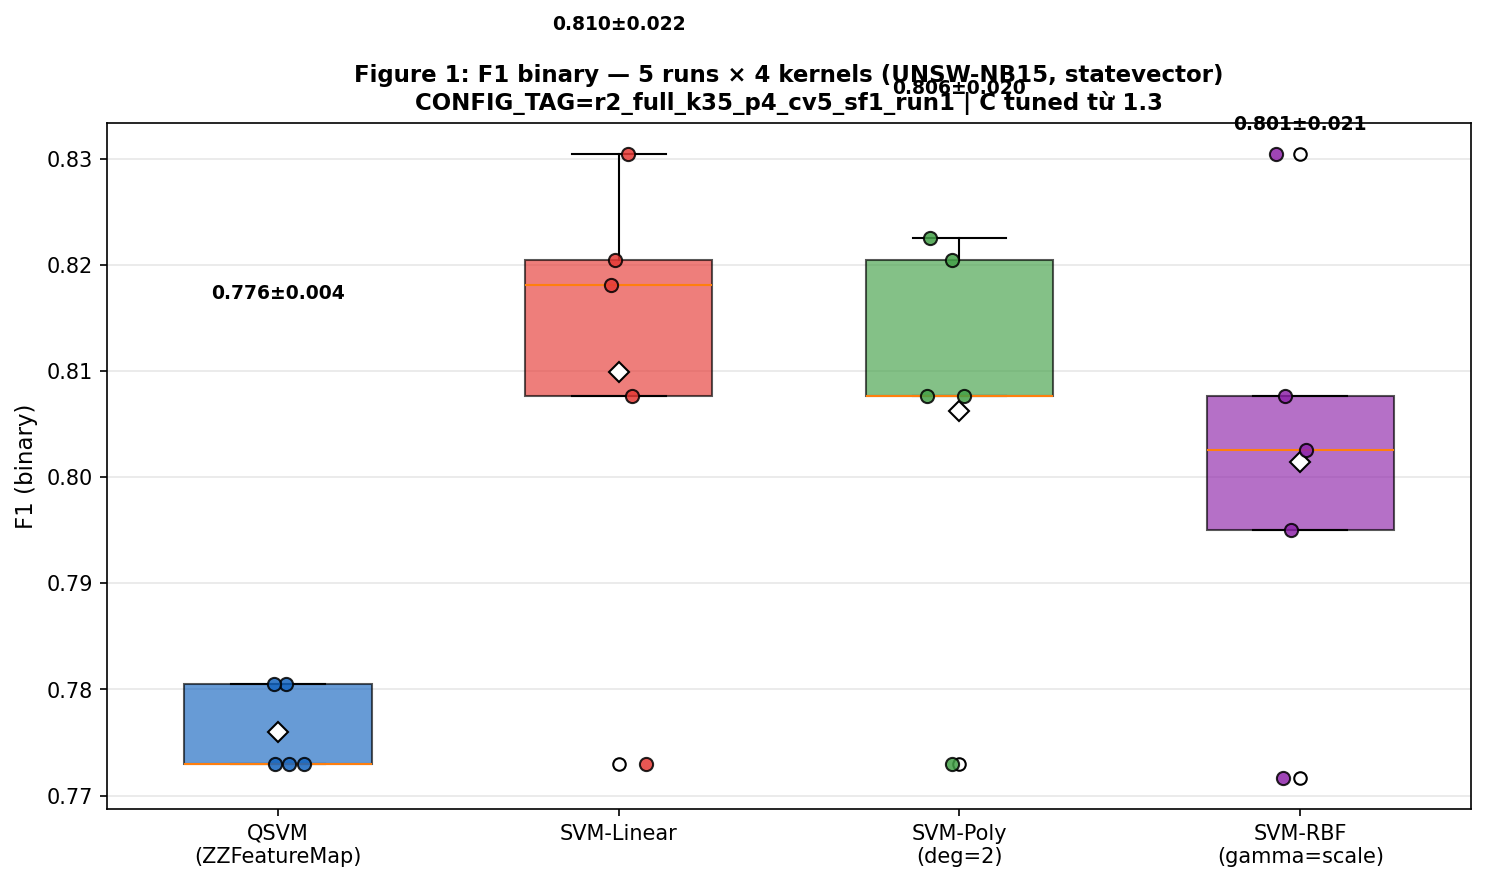

In [10]:
# ── Figure 1: F1 boxplot 4 kernels ────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(10, 6))
data_box = [per_run_df[per_run_df["kernel"]==k]["f1"].values for k in KERNEL_NAMES]
bp = ax1.boxplot(data_box, labels=[DISPLAY_NAMES[k] for k in KERNEL_NAMES],
                 patch_artist=True, widths=0.55, showmeans=True,
                 meanprops=dict(marker="D", markerfacecolor="white",
                                markeredgecolor="black", markersize=7))
for patch, k in zip(bp["boxes"], KERNEL_NAMES):
    patch.set_facecolor(COLORS[k]); patch.set_alpha(0.65)
# Scatter raw points
for i, k in enumerate(KERNEL_NAMES):
    ys = per_run_df[per_run_df["kernel"]==k]["f1"].values
    xs = np.random.normal(i+1, 0.05, size=len(ys))
    ax1.scatter(xs, ys, color=COLORS[k], edgecolor="black", s=40, zorder=3, alpha=0.85)
# Annotate mean±std
for i, k in enumerate(KERNEL_NAMES):
    m = agg.loc[k, "f1_mean"]; s = agg.loc[k, "f1_std"]
    ax1.text(i+1, ax1.get_ylim()[1]*0.98 if i==0 else m+s+0.01,
             f"{m:.3f}±{s:.3f}", ha="center", fontsize=9, fontweight="bold")
ax1.set_ylabel("F1 (binary)", fontsize=11)
ax1.set_title(f"Figure 1: F1 binary — 5 runs × 4 kernels (UNSW-NB15, statevector)\n"
              f"CONFIG_TAG={CONFIG_TAG} | C tuned từ 1.3", fontsize=11, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)
plt.tight_layout()
fig1_path = f"{REPORTS_DIR}/c3_multirun_statevector_f1_boxplot.png"
fig1.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.close(fig1)
print(f"[SAVED] {fig1_path}")
display(Image(fig1_path))

[SAVED] ../reports_unsw/c3_multirun_statevector_kta_bar.png


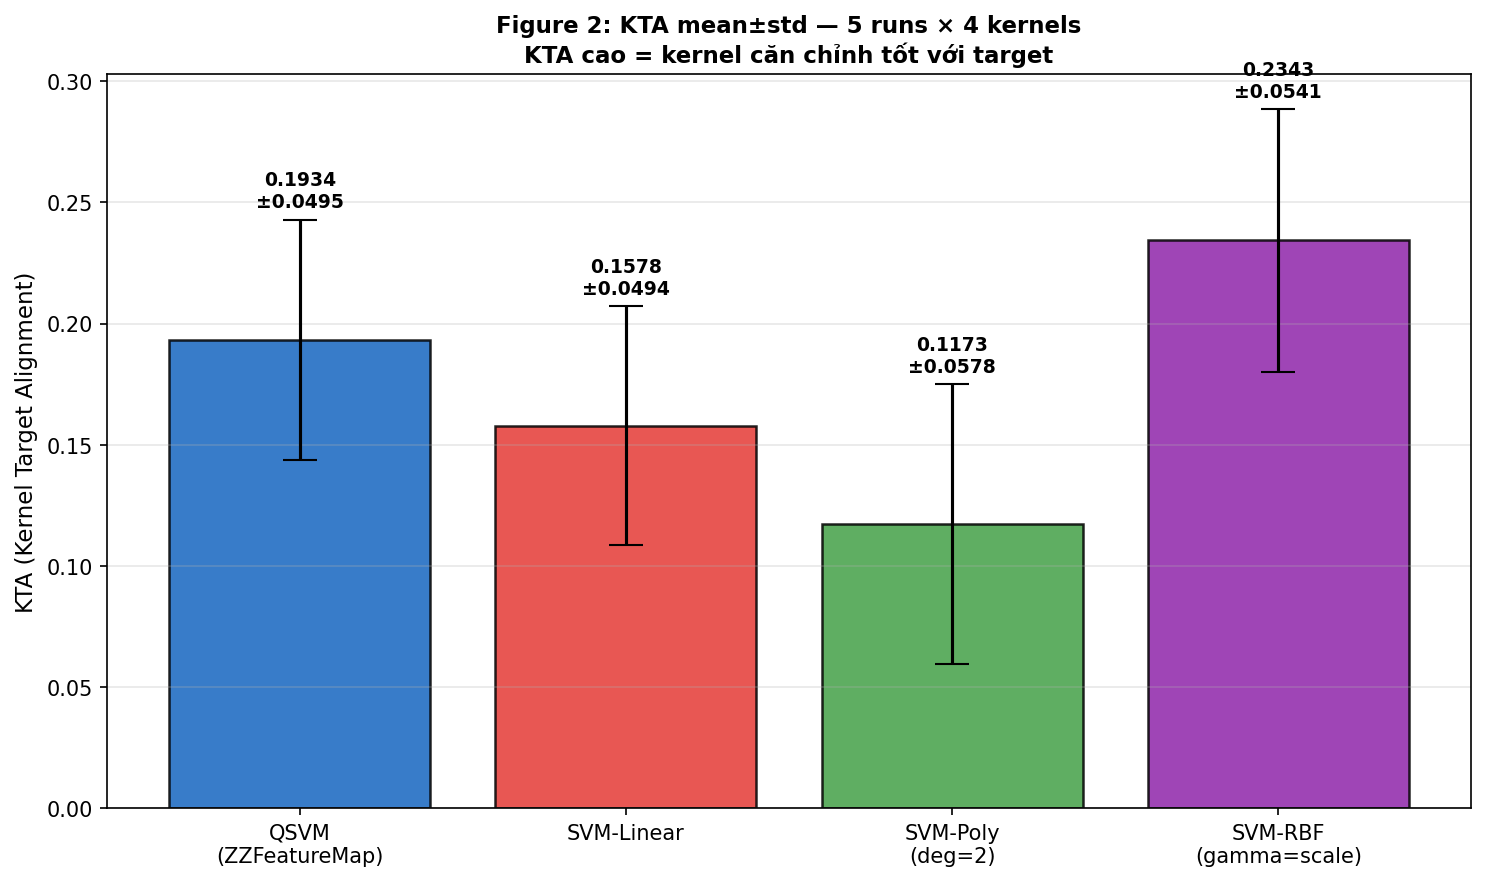

In [11]:
# ── Figure 2: KTA bar chart mean±std ──────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 6))
means = [agg.loc[k, "kta_mean"] for k in KERNEL_NAMES]
stds  = [agg.loc[k, "kta_std"]  for k in KERNEL_NAMES]
xpos  = np.arange(len(KERNEL_NAMES))
bars  = ax2.bar(xpos, means, yerr=stds, color=[COLORS[k] for k in KERNEL_NAMES],
                capsize=8, edgecolor="black", linewidth=1.2, alpha=0.85)
for i, (m, s) in enumerate(zip(means, stds)):
    ax2.text(i, m + s + 0.005, f"{m:.4f}\n±{s:.4f}",
             ha="center", fontsize=9, fontweight="bold")
ax2.set_xticks(xpos)
ax2.set_xticklabels([DISPLAY_NAMES[k] for k in KERNEL_NAMES])
ax2.set_ylabel("KTA (Kernel Target Alignment)", fontsize=11)
ax2.set_title(f"Figure 2: KTA mean±std — 5 runs × 4 kernels\n"
              f"KTA cao = kernel căn chỉnh tốt với target", fontsize=11, fontweight="bold")
ax2.grid(axis="y", alpha=0.3)
ax2.set_ylim(bottom=0)
plt.tight_layout()
fig2_path = f"{REPORTS_DIR}/c3_multirun_statevector_kta_bar.png"
fig2.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.close(fig2)
print(f"[SAVED] {fig2_path}")
display(Image(fig2_path))

Representative run = run_1 (QSVM F1=0.7805)


[SAVED] ../reports_unsw/c3_multirun_statevector_confmat.png


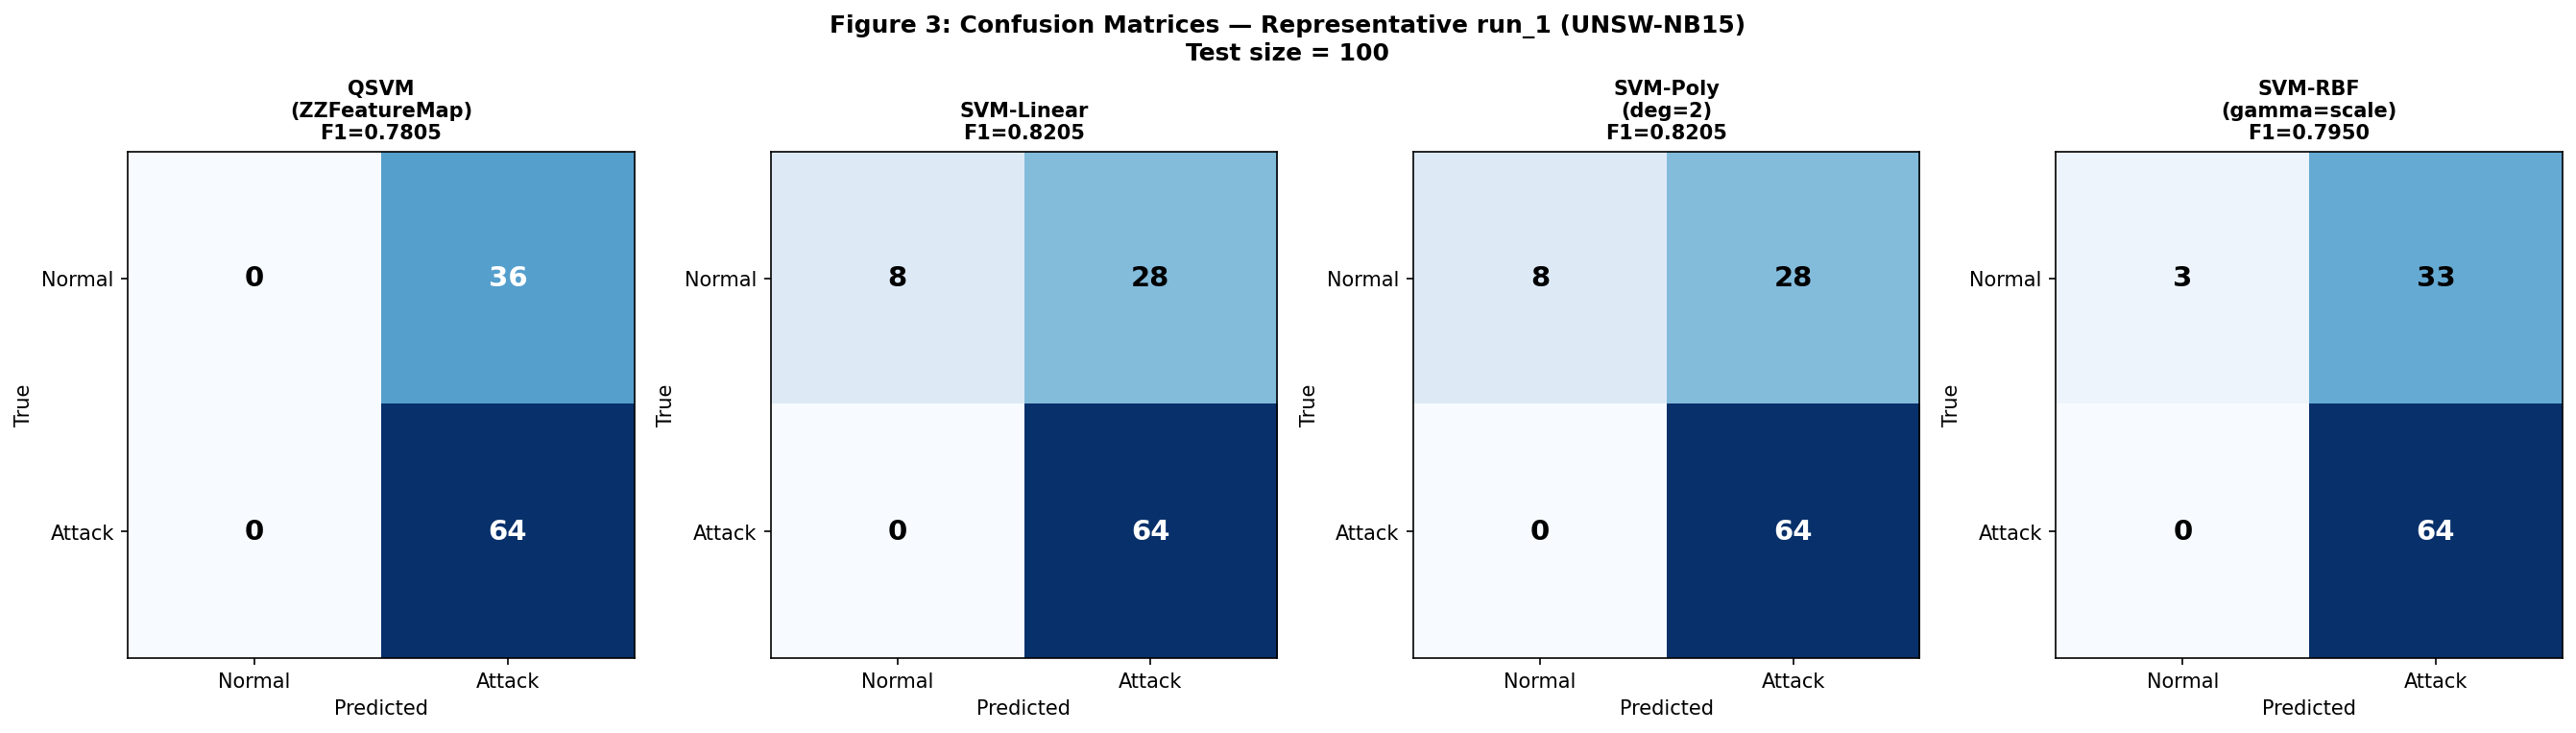

In [12]:
# ── Figure 3: Confusion matrices 4 kernels (representative run = F1 QSVM cao nhất) ──
q_f1_per_run = {rid: r["per_kernel"]["quantum"]["f1"] for rid, r in all_results.items()}
rep_run = max(q_f1_per_run, key=q_f1_per_run.get)
print(f"Representative run = run_{rep_run} (QSVM F1={q_f1_per_run[rep_run]:.4f})")

fig3, axes3 = plt.subplots(1, 4, figsize=(18, 5))
fig3.suptitle(f"Figure 3: Confusion Matrices — Representative run_{rep_run} (UNSW-NB15)\n"
              f"Test size = {len(all_results[rep_run]['y_test'])}", fontsize=12, fontweight="bold")
for ax, k in zip(axes3, KERNEL_NAMES):
    cm = np.array(all_results[rep_run]["per_kernel"][k]["cm"])
    f1 = all_results[rep_run]["per_kernel"][k]["f1"]
    im = ax.imshow(cm, cmap="Blues", vmin=0)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", fontsize=14,
                color="white" if v > cm.max()*0.55 else "black", fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Normal", "Attack"]); ax.set_yticklabels(["Normal", "Attack"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{DISPLAY_NAMES[k]}\nF1={f1:.4f}", fontsize=10, fontweight="bold")
plt.tight_layout()
fig3_path = f"{REPORTS_DIR}/c3_multirun_statevector_confmat.png"
fig3.savefig(fig3_path, dpi=150, bbox_inches="tight")
plt.close(fig3)
print(f"[SAVED] {fig3_path}")
display(Image(fig3_path))

## 9. Lưu JSON kết quả

In [13]:
import datetime

per_run_payload = []
for rid in RUN_IDS:
    res = all_results[rid]
    entry = {"run": rid}
    for k in KERNEL_NAMES:
        m = res["per_kernel"][k]
        entry[k] = {
            "f1":        m["f1"],
            "precision": m["precision"],
            "recall":    m["recall"],
            "accuracy":  m["accuracy"],
            "kta":       m["kta"],
            "n_sv":      m["n_sv"],
            "C":         m["C"],
        }
    per_run_payload.append(entry)

summary_payload = {}
for k in KERNEL_NAMES:
    summary_payload[k] = {
        "f1_mean":       float(agg.loc[k, "f1_mean"]),
        "f1_std":        float(agg.loc[k, "f1_std"]),
        "precision_mean":float(agg.loc[k, "precision_mean"]),
        "precision_std": float(agg.loc[k, "precision_std"]),
        "recall_mean":   float(agg.loc[k, "recall_mean"]),
        "recall_std":    float(agg.loc[k, "recall_std"]),
        "accuracy_mean": float(agg.loc[k, "accuracy_mean"]),
        "accuracy_std":  float(agg.loc[k, "accuracy_std"]),
        "kta_mean":      float(agg.loc[k, "kta_mean"]),
        "kta_std":       float(agg.loc[k, "kta_std"]),
        "n_sv_mean":     float(agg.loc[k, "n_sv_mean"]),
        "n_sv_std":      float(agg.loc[k, "n_sv_std"]),
        "C":             float(C_BY_KERNEL[k]),
    }

mcnemar_payload = {
    "per_run":         mcnemar_per_run,
    "combined_b":      total_b,
    "combined_c":      total_c,
    "combined_n":      total_b + total_c,
    "p_value":         p_combined,
    "median_p_value":  float(np.median([r["p_value"] for r in mcnemar_per_run])),
    "test":            "exact_binomial_2sided",
    "comparison":      "QSVM vs RBF",
}

metadata_payload = {
    "regime":             "statevector",
    "backend":            "FidelityStatevectorKernel",
    "n_runs":             len(RUN_IDS),
    "C_tuned_from":       C_TUNING_JSON,
    "config_tag":         CONFIG_TAG,
    "n_qubits":           N_QUBITS,
    "k_select":           K_SELECT,
    "pca_n":              PCA_N,
    "zz_reps":            ZZ_REPS,
    "zz_entanglement":    ZZ_ENT,
    "poly_degree":        POLY_DEGREE,
    "rbf_gamma":          RBF_GAMMA,
    "random_state":       RANDOM_STATE,
    "date":               datetime.date.today().isoformat(),
    "data_dir":           DATA_DIR,
    "reports":            [
        f"{REPORTS_DIR}/c3_multirun_statevector_f1_boxplot.png",
        f"{REPORTS_DIR}/c3_multirun_statevector_kta_bar.png",
        f"{REPORTS_DIR}/c3_multirun_statevector_confmat.png",
    ],
}

final_payload = {
    "per_run":             per_run_payload,
    "summary":             summary_payload,
    "mcnemar_qsvm_vs_rbf": mcnemar_payload,
    "metadata":            metadata_payload,
}

with open(RESULTS_JSON, "w", encoding="utf-8") as fp:
    json.dump(final_payload, fp, indent=2, ensure_ascii=False)
print(f"[SAVED] {RESULTS_JSON}")
print(f"  per_run    : {len(per_run_payload)} runs × {len(KERNEL_NAMES)} kernels")
print(f"  summary    : {list(summary_payload.keys())}")
print(f"  mcnemar    : combined_n={mcnemar_payload['combined_n']}, p={mcnemar_payload['p_value']:.4g}")

[SAVED] ../models_unsw/c3_results_statevector.json
  per_run    : 5 runs × 4 kernels
  summary    : ['quantum', 'linear', 'poly', 'rbf']
  mcnemar    : combined_n=98, p=6.572e-05


## 10. Summary

In [14]:
print('=' * 76)
print('  UNSW-NB15 — C3 KERNEL GEOMETRY MULTI-RUN STATEVECTOR (5 RUNS × 4 KERNELS)')
print('=' * 76)
print(f'  CONFIG_TAG   : {CONFIG_TAG}')
print(f'  C tuned src  : {C_TUNING_JSON}')
print(f'  Regime       : statevector (noiseless), FidelityStatevectorKernel')
print()
print(f'  {"Kernel":>10}  {"C":>6}  {"F1 mean±std":>16}  {"Acc mean±std":>16}  {"KTA mean±std":>16}  {"nSV mean":>9}')
print('  ' + '-' * 86)
for k in KERNEL_NAMES:
    s = summary_payload[k]
    print(f'  {k:>10}  {s["C"]:>6g}  '
          f'{s["f1_mean"]:.4f}±{s["f1_std"]:.4f}    '
          f'{s["accuracy_mean"]:.4f}±{s["accuracy_std"]:.4f}    '
          f'{s["kta_mean"]:.4f}±{s["kta_std"]:.4f}    '
          f'{s["n_sv_mean"]:>6.1f}')

# Verdict
q = summary_payload['quantum']; r = summary_payload['rbf']
gap_f1  = q['f1_mean']  - r['f1_mean']
gap_kta = q['kta_mean'] - r['kta_mean']
print()
print(f'  QSVM vs RBF gap: ΔF1={gap_f1:+.4f}  ΔKTA={gap_kta:+.4f}')
print(f'  McNemar combined p-value: {p_combined:.6g}  '
      f'({"khác biệt" if p_combined < 0.05 else "không khác biệt"} thống kê)')
print('=' * 76)

  UNSW-NB15 — C3 KERNEL GEOMETRY MULTI-RUN STATEVECTOR (5 RUNS × 4 KERNELS)
  CONFIG_TAG   : r2_full_k35_p4_cv5_sf1_run1
  C tuned src  : ../models_unsw/c_tuning_results.json
  Regime       : statevector (noiseless), FidelityStatevectorKernel

      Kernel       C       F1 mean±std      Acc mean±std      KTA mean±std   nSV mean
  --------------------------------------------------------------------------------------
     quantum    0.01  0.7760±0.0041    0.6340±0.0055    0.1934±0.0495      59.4
      linear     0.1  0.8100±0.0222    0.7140±0.0607    0.1578±0.0494      50.6
        poly     0.1  0.8063±0.0199    0.7060±0.0537    0.1173±0.0578      47.8
         rbf       1  0.8015±0.0213    0.7140±0.0503    0.2343±0.0541      48.6

  QSVM vs RBF gap: ΔF1=-0.0255  ΔKTA=-0.0409
  McNemar combined p-value: 6.57224e-05  (khác biệt thống kê)
